# 03 · Reward vector & content-type fidelity

Two scorers: the **episode reward vector** (outcome-labeled quality) and the **content-type-aware
fidelity scorer** from the AgentWorld paper, used to judge how faithful a *predicted* observation is
to the real one.

In [1]:
from episodic.core import reward
from episodic.testing import make_episode
rv = reward.reward_vector(make_episode("ep_r", outcome="merged", feedback=["useful"]))
import json
print(json.dumps(rv["components"], indent=2))
print("composite:", rv["composite"])

{
  "normalized": {
    "test_pass": 1.0,
    "outcome": 1.0,
    "human_label": 1.0,
    "edit_focus": 0.25,
    "cost_efficiency": 0.5
  },
  "weights": {
    "test_pass": 0.3,
    "outcome": 0.3,
    "human_label": 0.2,
    "edit_focus": 0.1,
    "cost_efficiency": 0.1
  },
  "has_tests": true,
  "has_feedback": true,
  "has_cost": false
}
composite: 0.875


## Content-type-aware fidelity (AgentWorld §4.2)

Not all observation content should be matched exactly. The scorer classifies content and masks
**runtime metadata** (timestamps, PIDs, hashes) so non-reproducible noise isn't penalized —
*"a PID of 42731 is as acceptable as the real 18204, provided both are valid."*

In [2]:
from episodic import fidelity

cases = {
    "exact":        ("Build succeeded in 12 steps", "Build succeeded in 12 steps"),
    "runtime-noise":("done pid 42731 at 2026-06-14T11:22:33Z", "done pid 18204 at 2026-06-14T10:00:00Z"),
    "fabrication":  ("file written and database dropped", "file written"),
    "wrong-type":   ("Error: build failed", "Build succeeded"),
}
import pandas as pd
rows = []
for label, (pred, gt) in cases.items():
    s = fidelity.score_observation(pred, gt)
    rows.append({"case": label, **{d: s[d] for d in fidelity.DIMENSIONS}, "composite": s["composite"]})
df = pd.DataFrame(rows).set_index("case")
df

,format,factuality,consistency,realism,quality,composite
case,,,,,,
exact,1.0,1.0,1.0,1.0,1.0000,1.00
runtime-noise,1.0,1.0,1.0,1.0,1.0000,1.00
fabrication,1.0,1.0,0.4,1.0,0.0000,0.73
wrong-type,1.0,0.0,0.0,0.0,0.7333,0.26


The five dimensions (Format · Factuality · Consistency · Realism · Quality) per case:

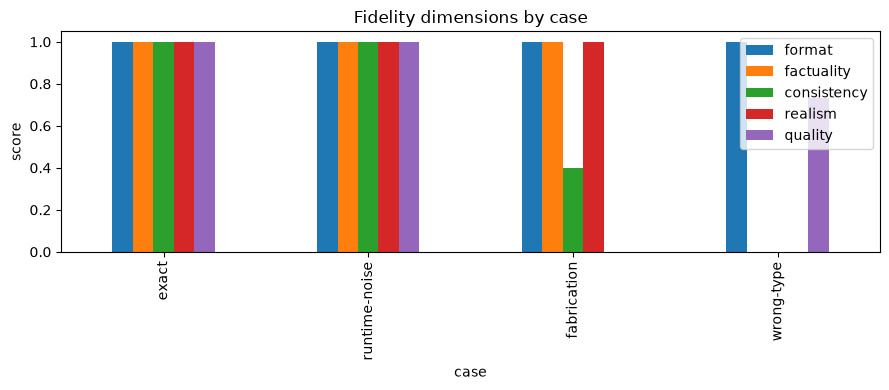

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
ax = df[list(fidelity.DIMENSIONS)].plot(kind="bar", figsize=(9, 4))
ax.set_ylim(0, 1.05); ax.set_ylabel("score"); ax.set_title("Fidelity dimensions by case")
plt.tight_layout(); plt.show()

`classify_content` exposes the content-type split the scorer uses:

In [4]:
info = fidelity.classify_content('{"pid": 42731, "ts": "2026-06-14T10:00:00Z", "ok": true}')
print(info)

{'deterministic': 5, 'pre_existing': 0, 'runtime_metadata': 1, 'lines': 1, 'chars': 56, 'is_json': True, 'response_type': 'success'}
